In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

In [67]:
#DEFINE SCALING RELATION
    
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772
    
#DEFINE SLIDING AUTOCORRELATION
    
def sliding_acf_search(frequency, power_flat, numax_grid,k_width=4.0,lag_frac=(0.8, 1.2)):
    
    acf_strength = []
    
    for nu_c in numax_grid:
    
        # Δν estimate
        dnu = delta_nu_from_numax(nu_c)
    
        # Window size
        W = k_width * dnu
    
        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue
    
        # Local, whitened spectrum
        p = power_flat[mask]
        p = p / np.median(p)
    
        # Autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:]
    
        # Lag axis
        df = frequency[1] - frequency[0]
        lag = np.arange(acf.size) * df
    
        # Measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])
    
        acf_strength.append(strength)
    
    return np.array(acf_strength)

#DEFINE MASK AROUND DELTA_NU_EST PEAK

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.2):
        """
        Mask ACF around delta_nu, excluding delta_nu/2 and 3*delta_nu/2.
    
        Parameters
        ----------
        lags : array
            Lag values (µHz)
        acf : array
            ACF values
        delta_nu_est : float
            Estimated large separation (µHz)
        window_frac : float
            Fractional half-width of the delta_nu window (e.g. 0.2 = ±20%)
    
        Returns
        -------
        lags_masked, acf_masked
        """
    
        # Central window around delta_nu
        main_lo = delta_nu_est * (1 - window_frac)
        main_hi = delta_nu_est * (1 + window_frac)
    
        # Exclusion windows
        half_lo = 0.5 * delta_nu_est * (1 - window_frac)
        half_hi = 0.5 * delta_nu_est * (1 + window_frac)
    
        three_half_lo = 1.5 * delta_nu_est * (1 - window_frac)
        three_half_hi = 1.5 * delta_nu_est * (1 + window_frac)
    
        mask = (
            (lags > main_lo) & (lags < main_hi) &
            ~((lags > half_lo) & (lags < half_hi)) &
            ~((lags > three_half_lo) & (lags < three_half_hi))
        )
    
        return lags[mask], acf[mask]

#GENERATE NOISE

def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_low, noise_high):
    # freqs: list of frequencies of the data
    # N: number of different fake signals
    # Noise_low/high: lower and upper bounds of the whitenoise level
    signals= []
    for i in range(0,N):
        noise_lvl=np.random.uniform(noise_low,noise_high)
        fake_base=[noise_lvl]*len(freqs)
        fake_signal=random(fake_base)
        signals.append(fake_signal)
    return np.array(signals)

In [125]:
#PARAMETERS FOR NOISE

delta_t = 58.9 #s
nu_nyq = 1/(2*delta_t) * 10**(6)
print(f"Nyquist frequecny: {nu_nyq:.2f}")

T = 30*24*60*60 #30 days
N = int(T/(2*delta_t))
print(f"Number of data points: {N}")

freq=np.linspace(0,nu_nyq,N)
powers=fake_signals(freq,1000,0.01,1)

Nyquist frequecny: 8488.96
Number of data points: 22003


In [127]:
nu_max_metrics = []
delta_nu_metrics = []
for power in tqdm(powers):
    #SMOOTHING
    
    df = np.median(np.diff(freq))  # µHz
    smooth_width_muHz = 600
    smooth_width_bins = int(smooth_width_muHz / df)
    background = uniform_filter1d(power, size =smooth_width_bins)
    power_flat = power / background
    
    #CALL SLIDING AUTOCORRELATOR, GET NU_MAX_METRIC
    
    numax_grid = np.linspace(50, 5000, 1000)
    
    acf_power = sliding_acf_search(
        freq,
        power_flat,
        numax_grid,
        k_width=4.0
    )
    nu_max_peak = np.max(acf_power)
    baseline = np.median(acf_power)
    scatter = np.std(acf_power)
    strength = (nu_max_peak - baseline) / scatter
    nu_max_metrics.append(strength)
    
    numax_est = numax_grid[np.argmax(acf_power)]
    
    #RUN AUTOCORRELATION AROUND DELTA_NU_EST
    
    delta_nu_est = delta_nu_from_numax(numax_est)
    width = 4* delta_nu_est
    mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
    freq_window = freq[mask]
    power_window = power[mask]
    
    acf_full = np.correlate(power_window, power_window, mode="full")
    N = len(power_window)
    acf = acf_full[N-1:]
    lags_bins = np.arange(len(acf))
    lags_muHz = lags_bins * df
    acf /= acf[0]
    
    #FIND ACF MAX WITHIN MASK, GIVING DELTA_NU_METRIC
    
    lags_fit, acf_fit = mask_acf_for_deltanu(
        lags_muHz,
        acf,
        delta_nu_est,
        window_frac=0.2
    )
    
    delta_nu_metric = np.max(acf_fit)
    delta_nu_metrics.append(delta_nu_metric)

print(nu_max_metrics)
print(delta_nu_metrics)

100%|██████████| 1000/1000 [06:56<00:00,  2.40it/s]

[np.float64(2.5671595286102566), np.float64(2.1924959054080313), np.float64(1.6934588628143814), np.float64(2.0686212762039875), np.float64(2.191330803469591), np.float64(1.9680640552966235), np.float64(2.2755289491961714), np.float64(2.801506463570384), np.float64(2.7429235196339605), np.float64(1.9321328977605707), np.float64(2.369882232742834), np.float64(1.7679770620561708), np.float64(2.582260015892211), np.float64(2.0350053002391686), np.float64(2.3485983520266127), np.float64(3.4753376094042423), np.float64(2.472342052849504), np.float64(2.1419895634287265), np.float64(2.3892964300727373), np.float64(2.0548911659538636), np.float64(1.9491943121361652), np.float64(3.0999723152658585), np.float64(3.2993483458377795), np.float64(2.75876676254923), np.float64(1.880016204584737), np.float64(2.0554538776939535), np.float64(2.470210742613628), np.float64(3.9879800220603108), np.float64(2.498571941409378), np.float64(2.3459199356559033), np.float64(2.1232632221982852), np.float64(2.0180

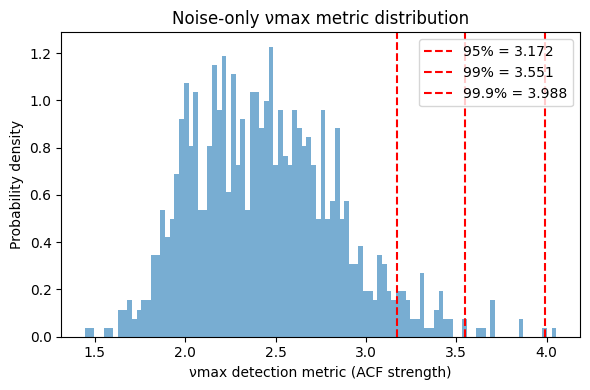

In [131]:
plt.figure(figsize=(6,4))
plt.hist(nu_max_metrics, bins=100, density=True, alpha = 0.6)

for p in [95, 99, 99.9]:
    thr = np.percentile(nu_max_metrics, p)
    plt.axvline(thr, linestyle="--", label=f"{p}% = {thr:.3f}", color = "r")
plt.xlabel("νmax detection metric (ACF strength)")
plt.ylabel("Probability density")
plt.title("Noise-only νmax metric distribution")
plt.legend()
plt.tight_layout()
plt.show()